In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.io import imread
from sklearn.model_selection import train_test_split
import keras
from tensorflow.keras.models import Sequential
from keras.applications import MobileNetV2
from keras.layers import Dense
from tensorflow.keras.preprocessing import image
import pandas as pd
import numpy as np
import os

In [6]:
brain_df = pd.read_csv("Brain Tumor.csv", usecols=[0, 1])
brain_df.head()


,Image,Class
0,Image1,0
1,Image2,0
2,Image3,1
3,Image4,1
4,Image5,0


In [7]:
brain_df.isna().sum()

Image    0
Class    0
dtype: int64

In [8]:
brain_df['Class'].value_counts()

Class
0    2079
1    1683
Name: count, dtype: int64

<Axes: ylabel='count'>

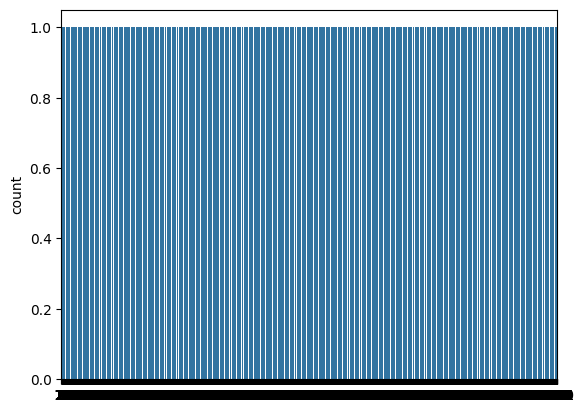

In [9]:
sns.countplot(brain_df['Class'])

In [11]:
import zipfile

zip_ref = zipfile.ZipFile("Brain Scans.zip", "r")
zip_ref.extractall(".")
zip_ref.close()


In [13]:
path_list = []

base_path = "Brain Scans/Brain Scans/Brain Tumor"

for entry in os.listdir(base_path):
    path_list.append(os.path.join(base_path, entry))

len(path_list)


3762

In [14]:
pathes_dict={os.path.splitext(os.path.basename(x))[0]: x for x in path_list}
brain_df['pathes'] = brain_df['Image'].map(pathes_dict.get)

In [15]:
brain_df.head()

,Image,Class,pathes
0,Image1,0,Brain Scans/Brain Scans/Brain Tumor\Image1.jpg
1,Image2,0,Brain Scans/Brain Scans/Brain Tumor\Image2.jpg
2,Image3,1,Brain Scans/Brain Scans/Brain Tumor\Image3.jpg
3,Image4,1,Brain Scans/Brain Scans/Brain Tumor\Image4.jpg
4,Image5,0,Brain Scans/Brain Scans/Brain Tumor\Image5.jpg


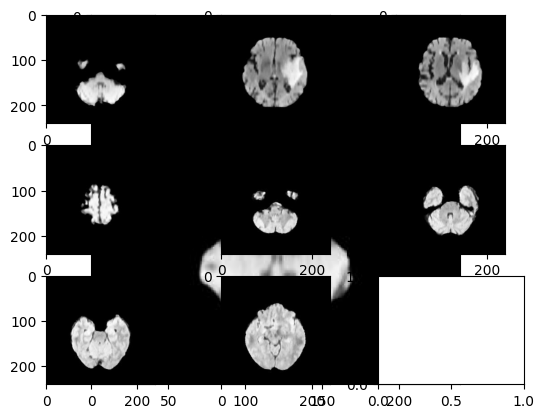

In [17]:
for x in range (0 ,9):
    img = imread(brain_df['pathes'][x])
    plt.imshow(img)
    plt.subplot(3,3,x+1)

In [18]:
from PIL.Image import open
brain_df['pixels']=brain_df['pathes'].map(lambda x:np.asarray(open(x).resize((224,224))))

In [19]:
brain_df.head()

,Image,Class,pathes,pixels
0,Image1,0,Brain Scans/Brain Scans/Brain Tumor\Image1.jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."
1,Image2,0,Brain Scans/Brain Scans/Brain Tumor\Image2.jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."
2,Image3,1,Brain Scans/Brain Scans/Brain Tumor\Image3.jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."
3,Image4,1,Brain Scans/Brain Scans/Brain Tumor\Image4.jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."
4,Image5,0,Brain Scans/Brain Scans/Brain Tumor\Image5.jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ..."


In [20]:
image_list = []
for i in range(0,len(brain_df)):
    # load image
    brain_img = brain_df['pixels'][i].astype(np.float32)
    img_array = image.img_to_array(brain_img)
     # append to list of all images
    image_list.append(keras.applications.mobilenet_v2.preprocess_input(img_array))

# convert image list to single array
# Our feature
X = np.array(image_list)

# print shape of X
print(X.shape)

(3762, 224, 224, 3)


In [21]:
y = np.array(brain_df.Class)

In [22]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(3762,))

In [23]:
X_train,X_test,y_train,y_test = train_test_split(X,y
                                                 ,test_size=0.2
                                                ,random_state=0)


print('The shape of the X_train :'+' '+str(X_train.shape))
print('The size of the X_train :'+' '+str(X_train.shape[0]))
print('The shape of the X_test :'+' '+str(X_test.shape))
print('The size of the X_test:'+' '+str(X_test.shape[0]))

The shape of the X_train : (3009, 224, 224, 3)
The size of the X_train : 3009
The shape of the X_test : (753, 224, 224, 3)
The size of the X_test: 753


In [24]:
num_classes = 1
model = Sequential()
model.add(MobileNetV2(input_shape=(224, 224, 3),weights="imagenet"
                             ,include_top=False))
model.add(keras.layers.GlobalAveragePooling2D())
model.add( Dense(num_classes, activation='sigmoid',name='preds'))
model.layers[0].trainable= False
# show model summary
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 5s 1us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preds (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
model.compile(optimizer = 'adam', loss = 'hinge', metrics = ['accuracy'])


# mock-train the model
model.fit(
    X_train,
    y_train,
    epochs=5,
    verbose=1,
    validation_data=(X_test, y_test)
)
model.save("model_brain.h5")
print("Saved model to disk")

Epoch 1/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.5517 - loss: 1.0065 - val_accuracy: 0.5339 - val_loss: 0.9703
Epoch 2/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 89s 937ms/step - accuracy: 0.8019 - loss: 0.7904 - val_accuracy: 0.8313 - val_loss: 0.7260
Epoch 3/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.8664 - loss: 0.7226 - val_accuracy: 0.8499 - val_loss: 0.7027
Epoch 4/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.8890 - loss: 0.7021 - val_accuracy: 0.8685 - val_loss: 0.6943
Epoch 5/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 93s 979ms/step - accuracy: 0.8943 - loss: 0.6916 - val_accuracy: 0.8659 - val_loss: 0.6908


Saved model to disk


In [26]:
pretrained_cnn = keras.models.load_model('./model_brain.h5')

# evaluate model on holdout set
eval_score = pretrained_cnn.evaluate(X_test,y_test)
# print loss score
print('Eval loss:',eval_score[0])
# print accuracy score
print('Eval accuracy:',eval_score[1] )

24/24 ━━━━━━━━━━━━━━━━━━━━ 25s 741ms/step - accuracy: 0.8659 - loss: 0.6908
Eval loss: 0.6907840371131897
Eval accuracy: 0.8658698797225952


In [27]:
y_pred = (pretrained_cnn.predict(X_test) > 0.5).astype("int32")

24/24 ━━━━━━━━━━━━━━━━━━━━ 25s 695ms/step


In [28]:
from sklearn.metrics import confusion_matrix , classification_report
target_classes = ['No Tumor','Tumor']
classification_report(y_test , y_pred , output_dict = True
                      , target_names=target_classes)

{'No Tumor': {'precision': 0.9164345403899722,
  'recall': 0.8225,
  'f1-score': 0.8669301712779973,
  'support': 400.0},
 'Tumor': {'precision': 0.8197969543147208,
  'recall': 0.9150141643059491,
  'f1-score': 0.8647925033467202,
  'support': 353.0},
 'accuracy': 0.8658698539176627,
 'macro avg': {'precision': 0.8681157473523464,
  'recall': 0.8687570821529745,
  'f1-score': 0.8658613373123587,
  'support': 753.0},
 'weighted avg': {'precision': 0.8711316613932076,
  'recall': 0.8658698539176627,
  'f1-score': 0.8659280507205726,
  'support': 753.0}}

In [29]:
confusion_matrix(y_test , y_pred )

array([[329,  71],
       [ 30, 323]])

In [30]:
model.save("brain_tumor_model.h5")


